# CRYCHIC 最新完整文献 benchmark：结果复现与可视化

本 notebook 从 checksum-bound 的最新 complete 发布表重建结果图，不重新运行耗时的原始算法。覆盖：

- **CITE-seq 7/7 数据集**：ADT receptor-protein truth；固定资源主比较按 human/mouse 分面。
- **CytoSig 2/2 数据集**：TNBC 与 HER2；展示 controlled ligand-target AUROC、AP、balanced AP 及 top-250 Fisher OR。
- **IPF 完整队列**：4 studies、56 patients、138,248 cells、168/168 tasks；展示患者等权指标、bootstrap 区间和 study 异质性。
- **稳健性**：8 个方法、4 类 perturbation 的 top-250 recovery。

当前结果支持“CRYCHIC 在若干数据集和指标领先”，不支持“全面优于所有方法”：IPF 的 AP/balanced AUPRC 为 1/11、AUROC 为 2/11；HER2 CytoSig 三个 controlled 指标为 1/12，但 TNBC AUROC 为 11/12；CITE-seq 固定资源臂也存在明显的数据集异质性。发布表没有逐阈值 ROC 坐标，因此下面画 AUROC/AP 指标图，而不从一个标量伪造 ROC curve。


In [1]:
%%time
from __future__ import annotations

import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

import crychic

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


def find_repo_root() -> Path:
    explicit = os.environ.get("CRYCHIC_REPO_ROOT")
    candidates = []
    if explicit:
        candidates.append(Path(explicit).expanduser())
    candidates.extend((Path.cwd(), *Path.cwd().parents))
    installed = Path(crychic.__file__).resolve()
    candidates.extend(installed.parents)
    for candidate in candidates:
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src/crychic").is_dir()
        ):
            return candidate.resolve()
    raise FileNotFoundError("Cannot locate the CRYCHIC repository root")


REPO_ROOT = find_repo_root()
PUBLIC_ROOT = (
    REPO_ROOT / "docs/benchmarks/literature_extension_20260717"
)
literature_candidates = []
if os.environ.get("CRYCHIC_LITERATURE_ROOT"):
    literature_candidates.append(
        Path(os.environ["CRYCHIC_LITERATURE_ROOT"]).expanduser()
    )
literature_candidates.extend(
    [
        REPO_ROOT.parent / "benchmark_work/literature_reproduction",
        REPO_ROOT / "benchmark_work/literature_reproduction",
    ]
)
LITERATURE_ROOT = next(
    (
        candidate.resolve()
        for candidate in literature_candidates
        if (candidate / "cytokine").is_dir()
    ),
    None,
)
OUTPUT_ROOT = Path(
    os.environ.get(
        "CRYCHIC_TUTORIAL_OUTPUT_DIR",
        "tutorial_output/literature_benchmark_results",
    )
).expanduser()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CRYCHIC_COLOR = "#176B87"
EXTERNAL_COLOR = "#A7ADB4"
ACCENT_COLOR = "#C65D3B"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "font.size": 9,
    }
)
print(
    f"CRYCHIC {crychic.__version__}; "
    f"published_bundle={PUBLIC_ROOT.is_dir()}; "
    f"workspace_detail={LITERATURE_ROOT is not None}"
)


CRYCHIC 0.0.0; published_bundle=True; workspace_detail=True
CPU times: user 14.5 s, sys: 416 ms, total: 14.9 s
Wall time: 1.92 s


## 1. 完整性与 provenance

主 manifest 必须同时满足 `status=complete`、CITE-seq 7/7、CytoSig 2/2、IPF 168/168。每张输入小表在读取前重新计算 SHA256。发布 bundle 位于当前代码提交中，但原始 benchmark 的记录提交为 `87153a3...` 且生成时 worktree 为 dirty；这项限制必须随结果展示。


In [2]:
%%time
def read_json(path: Path) -> dict[str, object]:
    with path.open(encoding="utf-8") as handle:
        value = json.load(handle)
    if not isinstance(value, dict):
        raise TypeError(f"Expected a JSON object: {path.name}")
    return value


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


public_manifest = read_json(PUBLIC_ROOT / "manifest.json")
headline = public_manifest["headline"]
assert public_manifest["status"] == "complete"
assert headline["citeseq_datasets_complete"] == headline[
    "citeseq_datasets_expected"
] == 7
assert headline["cytosig_datasets_complete"] == headline[
    "cytosig_datasets_expected"
] == 2
assert headline["ipf_tasks_complete"] == headline[
    "ipf_tasks_expected"
] == 168

audited_public_files = (
    "citeseq/dataset_inventory.tsv",
    "citeseq/metrics_by_dataset.tsv",
    "citeseq/method_summary.tsv",
    "citeseq/skipped_arms.tsv",
    "cytosig_her2/ranking_metrics.tsv",
    "cytosig_her2/fisher_rank_curves.tsv",
    "ipf/cohort_patient_equal.tsv",
    "ipf/metrics_by_study.tsv",
    "ipf/patient_bootstrap.tsv",
    "tables/cytosig_extension_summary.tsv",
    "tables/ipf_primary_metrics.tsv",
)
checksum_records = []
for relative in audited_public_files:
    path = PUBLIC_ROOT / relative
    record = public_manifest["outputs"][relative]
    observed = sha256_file(path)
    assert observed == record["sha256"]
    checksum_records.append(
        {
            "artifact": relative,
            "bytes": path.stat().st_size,
            "sha256_ok": True,
        }
    )

try:
    current_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    current_commit = "unavailable"

provenance_summary = pd.DataFrame(
    [
        {
            "bundle_status": public_manifest["status"],
            "generated_on": public_manifest["generated_on"],
            "source_run_commit": public_manifest[
                "repository_state_at_run"
            ]["commit"],
            "source_run_dirty": public_manifest[
                "repository_state_at_run"
            ]["dirty"],
            "current_checkout_commit": current_commit[:12],
            "audited_tables": len(checksum_records),
        }
    ]
)
provenance_summary


CPU times: user 2.78 ms, sys: 2.02 ms, total: 4.8 ms
Wall time: 26.5 ms


,bundle_status,generated_on,source_run_commit,source_run_dirty,current_checkout_commit,audited_tables
0,complete,2026-07-17,87153a38e7fe377881e1d6cd97715aa4f28beba1,True,247ab24af0fd,11


In [3]:
%%time
cite_inventory = pd.read_csv(
    PUBLIC_ROOT / "citeseq/dataset_inventory.tsv", sep="	"
)
cyto_overview = pd.read_csv(
    PUBLIC_ROOT / "tables/cytosig_extension_summary.tsv", sep="	"
)
ipf_publication_manifest = read_json(PUBLIC_ROOT / "ipf/manifest.json")

assert len(cite_inventory) == 7
assert not cite_inventory["differential_inference_estimable"].any()
assert set(cyto_overview["dataset"]) == {"TNBC_Wu2021", "HER2_Wu2021"}
assert ipf_publication_manifest["status"] == "complete"
assert ipf_publication_manifest["execution"]["tasks_complete"] == 168

inventory_summary = pd.DataFrame(
    [
        {
            "benchmark": "CITE-seq receptor protein",
            "datasets_or_studies": len(cite_inventory),
            "samples_or_patients": int(cite_inventory["samples"].sum()),
            "cells": int(cite_inventory["cells"].sum()),
            "status": "7/7 complete",
        },
        {
            "benchmark": "CytoSig downstream response",
            "datasets_or_studies": 2,
            "samples_or_patients": int(
                cyto_overview.groupby("dataset", observed=True)["patients"]
                .max()
                .fillna(0)
                .sum()
            ),
            "cells": int(
                cyto_overview.groupby("dataset", observed=True)["cells"]
                .max()
                .sum()
            ),
            "status": "2/2 complete",
        },
        {
            "benchmark": "IPF literature gold",
            "datasets_or_studies": ipf_publication_manifest["cohort"][
                "studies"
            ],
            "samples_or_patients": ipf_publication_manifest["cohort"][
                "samples"
            ],
            "cells": ipf_publication_manifest["cohort"]["cells"],
            "status": "168/168 tasks complete",
        },
    ]
)
inventory_summary


CPU times: user 5.59 ms, sys: 1.98 ms, total: 7.57 ms
Wall time: 7.19 ms


,benchmark,datasets_or_studies,samples_or_patients,cells,status
0,CITE-seq receptor protein,7,7,65615,7/7 complete
1,CytoSig downstream response,2,5,61787,2/2 complete
2,IPF literature gold,4,56,138248,168/168 tasks complete


## 2. CITE-seq：7 个数据集的 receptor-protein 一致性

主比较只使用 `H-common/resource_fixed`；human 与 mouse 的冻结资源分别为 638 和 705 LR，不能混成一个资源无关总排名。CBMC 的 14 个 ADT truth receptor 与 human H-common 重叠为 0，因此是 `not_evaluable`，不是 0 分。Native 结果覆盖 7/7，但各方法资源不同，仅作描述。


In [4]:
%%time
cite_metrics = pd.read_csv(
    PUBLIC_ROOT / "citeseq/metrics_by_dataset.tsv", sep="	"
)
cite_skips = pd.read_csv(
    PUBLIC_ROOT / "citeseq/skipped_arms.tsv", sep="	"
)
assert not cite_metrics.duplicated(
    ["short_name", "comparison_arm", "method"]
).any()

cite_fixed = cite_metrics.loc[
    cite_metrics["comparison_arm"].eq("H-common/resource_fixed")
    & cite_metrics["status"].eq("observed")
].copy()
cite_native = cite_metrics.loc[
    cite_metrics["comparison_arm"].eq("native/independent")
    & cite_metrics["status"].eq("observed")
].copy()
assert cite_fixed["short_name"].nunique() == 6
assert set(cite_inventory.loc[cite_inventory["hcommon_status"].eq("not_evaluable"), "short_name"]) == {"cbmc"}
assert cite_native.loc[
    cite_native["method"].eq("CRYCHIC availability-state"), "short_name"
].nunique() == 7

rank_frames = []
for metric, label in (
    ("auroc", "AUROC"),
    ("average_precision", "AP"),
):
    ranked = cite_fixed.copy()
    ranked["rank"] = ranked.groupby(
        ["species", "short_name"], observed=True
    )[metric].rank(method="min", ascending=False)
    ranked["methods"] = ranked.groupby(
        ["species", "short_name"], observed=True
    )["method"].transform("nunique")
    selected = ranked.loc[
        ranked["method"].eq("CRYCHIC availability-state"),
        ["short_name", "species", metric, "rank", "methods"],
    ].rename(columns={metric: "value"})
    selected["metric"] = label
    rank_frames.append(selected)
cite_crychic_ranks = pd.concat(rank_frames, ignore_index=True)

observed_order = [
    value
    for value in cite_inventory["short_name"]
    if value != "cbmc"
]
expected_auroc = dict(
    zip(observed_order, (1, 6, 1, 1, 1, 2), strict=True)
)
expected_ap = dict(
    zip(observed_order, (1, 11, 1, 1, 4, 1), strict=True)
)
for row in cite_crychic_ranks.itertuples(index=False):
    expected = expected_auroc if row.metric == "AUROC" else expected_ap
    assert int(row.rank) == expected[row.short_name]

cite_rank_table = cite_crychic_ranks.assign(
    rank_display=lambda frame: (
        frame["rank"].astype(int).astype(str)
        + "/"
        + frame["methods"].astype(int).astype(str)
    )
).loc[:, ["short_name", "species", "metric", "value", "rank_display"]]
cite_rank_table


CPU times: user 14.7 ms, sys: 971 μs, total: 15.6 ms
Wall time: 15.2 ms


,short_name,species,metric,value,rank_display
0,5k_pbmc,human,AUROC,0.548635,1/11
1,5k_pbmc_nextgem,human,AUROC,0.465043,6/11
2,pbmc_10k,human,AUROC,0.641593,1/11
3,malt_10k,human,AUROC,0.590926,1/11
4,sln_111,mouse,AUROC,0.626157,1/9
5,sln_208,mouse,AUROC,0.541101,2/9
6,5k_pbmc,human,AP,0.108965,1/11
7,5k_pbmc_nextgem,human,AP,0.070353,11/11
8,pbmc_10k,human,AP,0.174635,1/11
9,malt_10k,human,AP,0.174180,1/11


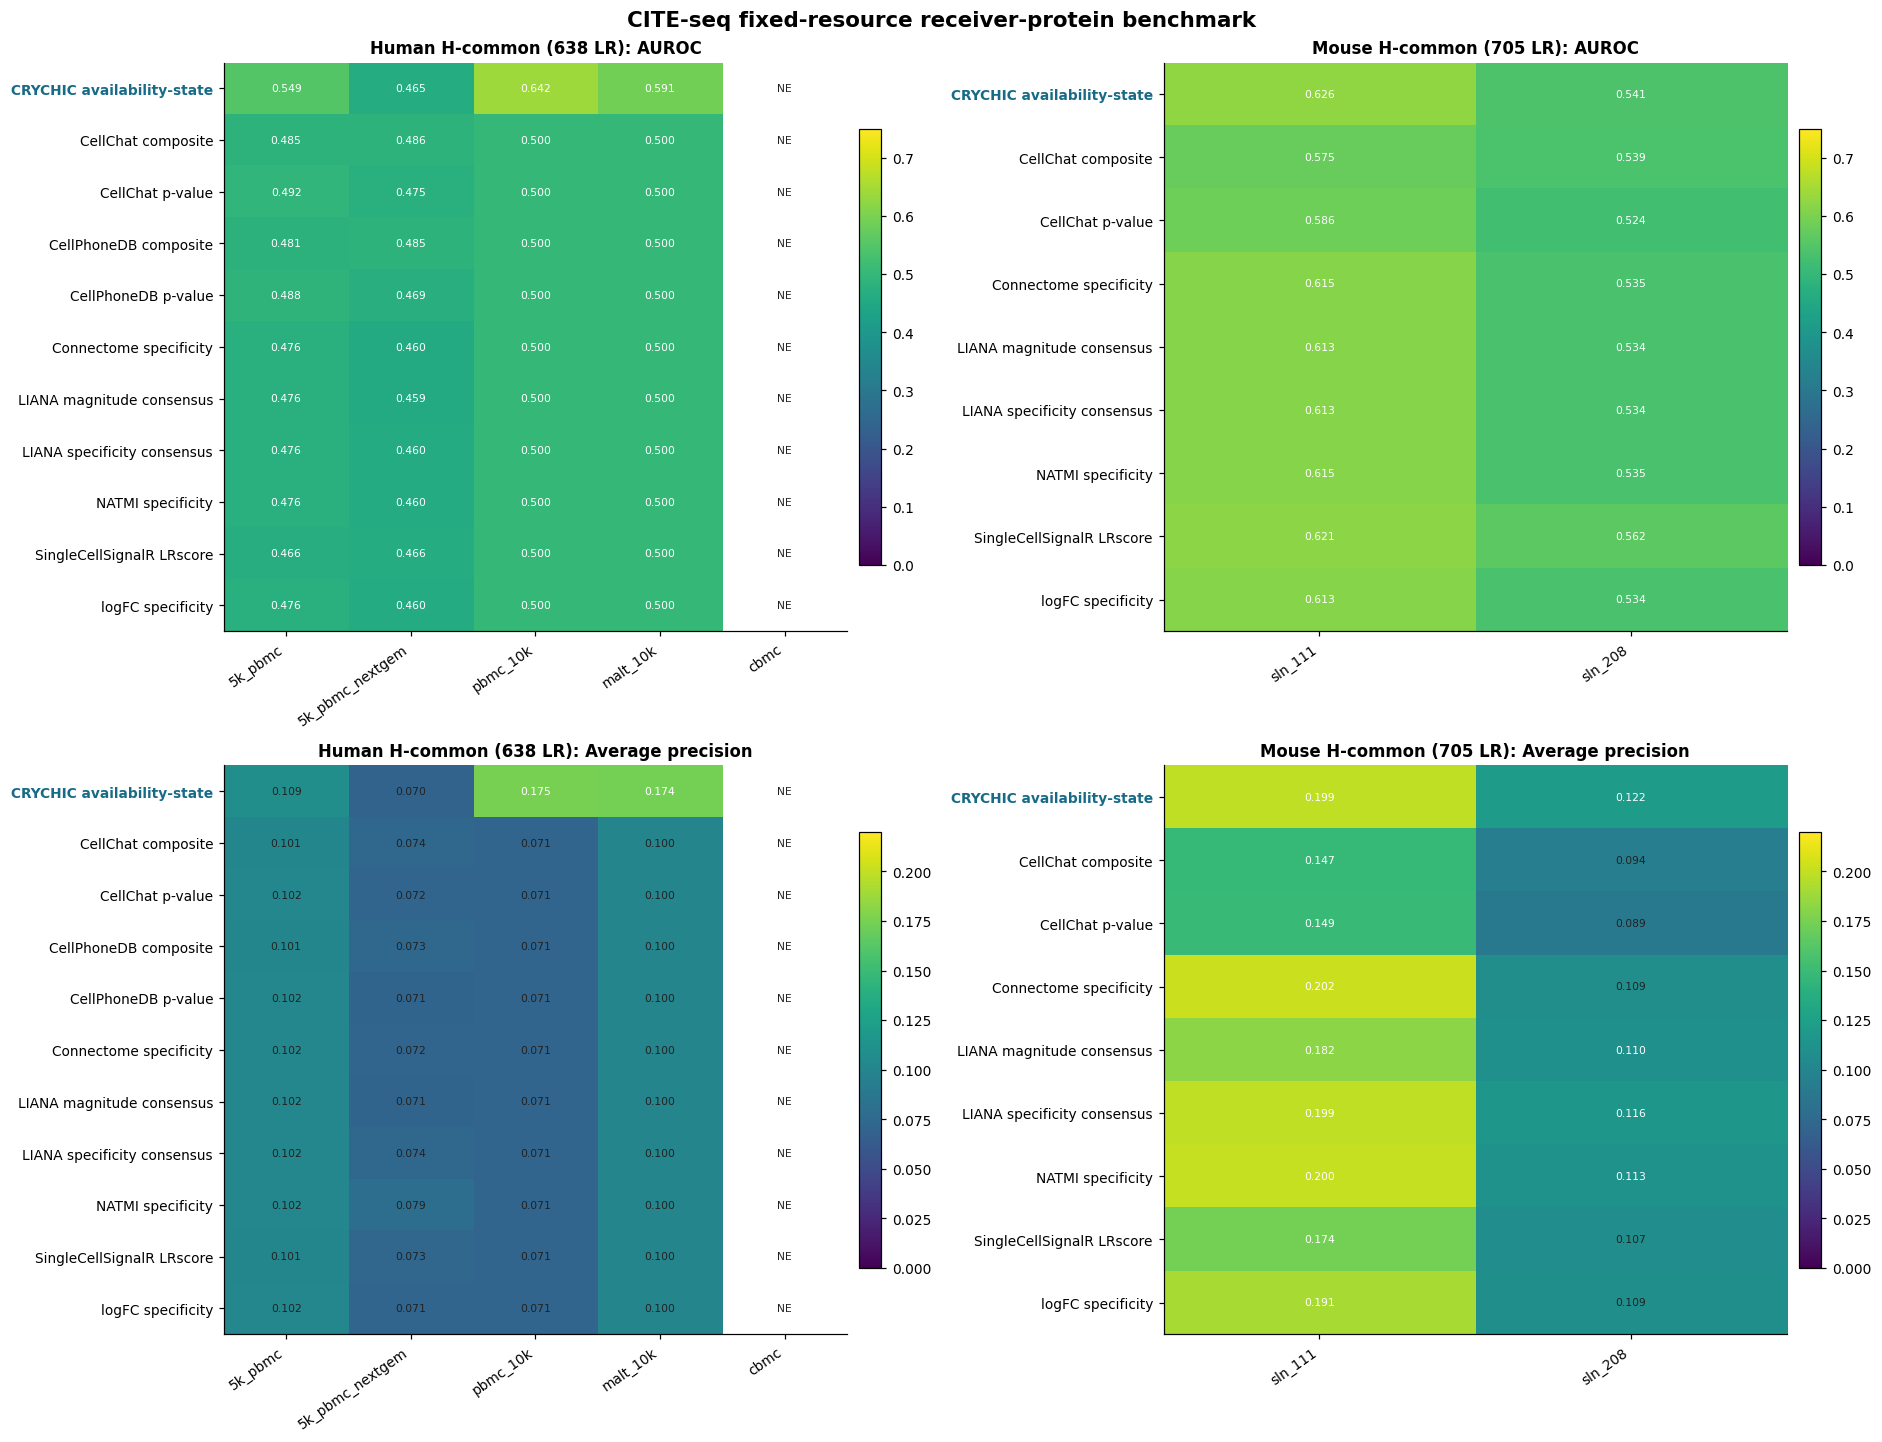

CPU times: user 2.54 s, sys: 6.08 s, total: 8.62 s
Wall time: 8.62 s


In [5]:
%%time
def draw_heatmap(
    ax: plt.Axes,
    table: pd.DataFrame,
    *,
    title: str,
    vmin: float,
    vmax: float,
    cmap: str = "viridis",
) -> None:
    values = table.to_numpy(dtype=float)
    image = ax.imshow(
        np.ma.masked_invalid(values),
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=35, ha="right")
    ax.set_yticks(range(table.shape[0]), table.index)
    ax.set_title(title)
    for row in range(table.shape[0]):
        for column in range(table.shape[1]):
            value = values[row, column]
            text = "NE" if not np.isfinite(value) else f"{value:.3f}"
            color = "#222222"
            if np.isfinite(value) and value > (vmin + vmax) / 2:
                color = "white"
            ax.text(column, row, text, ha="center", va="center", fontsize=7, color=color)
    for label in ax.get_yticklabels():
        if label.get_text() == "CRYCHIC availability-state":
            label.set_color(CRYCHIC_COLOR)
            label.set_fontweight("bold")
    plt.colorbar(image, ax=ax, fraction=0.035, pad=0.02)


fig, axes = plt.subplots(2, 2, figsize=(17, 13), constrained_layout=True)
resource_pairs = {"human": 638, "mouse": 705}
for row_index, (metric, metric_label, limits) in enumerate(
    (
        ("auroc", "AUROC", (0.0, 0.75)),
        ("average_precision", "Average precision", (0.0, 0.22)),
    )
):
    for column_index, species in enumerate(("human", "mouse")):
        species_data = cite_fixed.loc[cite_fixed["species"].eq(species)]
        dataset_order = cite_inventory.loc[
            cite_inventory["species"].eq(species), "short_name"
        ].tolist()
        method_order = sorted(
            species_data["method"].unique(),
            key=lambda value: (
                value != "CRYCHIC availability-state",
                value,
            ),
        )
        pivot = (
            species_data.pivot(
                index="method", columns="short_name", values=metric
            )
            .reindex(index=method_order, columns=dataset_order)
        )
        draw_heatmap(
            axes[row_index, column_index],
            pivot,
            title=(
                f"{species.capitalize()} H-common "
                f"({resource_pairs[species]} LR): {metric_label}"
            ),
            vmin=limits[0],
            vmax=limits[1],
        )
fig.suptitle(
    "CITE-seq fixed-resource receiver-protein benchmark",
    fontsize=14,
    fontweight="bold",
)
cite_figure = OUTPUT_ROOT / "citeseq_fixed_resource_metrics.png"
fig.savefig(cite_figure, bbox_inches="tight")
plt.show()


## 3. CytoSig：TNBC 与 HER2 下游响应一致性

受控主终点固定为 `controlled_unique_ligand_target + max`。TNBC 使用 OpenProblems 冻结 binary proxy，HER2 使用本轮重建的 43-signature clean activity truth，二者 truth 构造不同，不能求一个简单平均。HER2 的 CRYCHIC availability-state 在 AUROC/AP/balanced AP 均为 1/12；TNBC 分别为 11/12、8/12、8/12。CytoSig 是 receiver transcriptional-response 旁证，不是 LR 结合或因果通信证明。


In [6]:
%%time
def verify_manifest_output(
    manifest_path: Path, output_name: str, output_path: Path
) -> None:
    manifest = read_json(manifest_path)
    assert manifest["status"] == "complete"
    expected = manifest["outputs"][output_name]["sha256"]
    assert sha256_file(output_path) == expected


her2_metrics_path = PUBLIC_ROOT / "cytosig_her2/ranking_metrics.tsv"
her2_fisher_path = PUBLIC_ROOT / "cytosig_her2/fisher_rank_curves.tsv"
her2_metrics = pd.read_csv(her2_metrics_path, sep="	").assign(
    dataset="HER2_Wu2021"
)
her2_fisher = pd.read_csv(her2_fisher_path, sep="	").assign(
    dataset="HER2_Wu2021"
)

tnbc_detail_available = LITERATURE_ROOT is not None and (
    LITERATURE_ROOT
    / "cytokine/results/protocol_audit_v1/ranking_metrics.tsv"
).is_file()
if tnbc_detail_available:
    tnbc_root = LITERATURE_ROOT / "cytokine/results/protocol_audit_v1"
    tnbc_metrics_path = tnbc_root / "ranking_metrics.tsv"
    tnbc_fisher_path = tnbc_root / "fisher_rank_curves.tsv"
    verify_manifest_output(
        tnbc_root / "manifest.json",
        "ranking_metrics.tsv",
        tnbc_metrics_path,
    )
    verify_manifest_output(
        tnbc_root / "manifest.json",
        "fisher_rank_curves.tsv",
        tnbc_fisher_path,
    )
    tnbc_metrics = pd.read_csv(tnbc_metrics_path, sep="	").assign(
        dataset="TNBC_Wu2021"
    )
    tnbc_fisher = pd.read_csv(tnbc_fisher_path, sep="	").assign(
        dataset="TNBC_Wu2021"
    )
else:
    tnbc_metrics = pd.DataFrame(columns=her2_metrics.columns)
    tnbc_fisher = pd.DataFrame(columns=her2_fisher.columns)

cyto_metrics = pd.concat(
    [tnbc_metrics, her2_metrics], ignore_index=True, sort=False
)
cyto_fisher = pd.concat(
    [tnbc_fisher, her2_fisher], ignore_index=True, sort=False
)
controlled = cyto_metrics.loc[
    cyto_metrics["protocol"].eq("controlled_unique_ligand_target")
    & cyto_metrics["aggregation"].eq("max")
].copy()
assert controlled.loc[
    controlled["dataset"].eq("HER2_Wu2021"), "method_id"
].nunique() == 12
if tnbc_detail_available:
    assert controlled.loc[
        controlled["dataset"].eq("TNBC_Wu2021"), "method_id"
    ].nunique() == 12

cyto_rank_frames = []
for metric, label in (
    ("auroc", "AUROC"),
    ("average_precision", "AP"),
    ("balanced_average_precision_mean", "balanced AP"),
):
    frame = controlled.copy()
    frame["rank"] = frame.groupby("dataset", observed=True)[metric].rank(
        method="min", ascending=False
    )
    frame["methods"] = frame.groupby("dataset", observed=True)[
        "method_id"
    ].transform("nunique")
    selected = frame.loc[
        frame["method_id"].eq("crychic_availability_state"),
        ["dataset", metric, "rank", "methods"],
    ].rename(columns={metric: "value"})
    selected["metric"] = label
    cyto_rank_frames.append(selected)
cyto_state_ranks = pd.concat(cyto_rank_frames, ignore_index=True)

if tnbc_detail_available:
    expected = {
        ("TNBC_Wu2021", "AUROC"): 11,
        ("TNBC_Wu2021", "AP"): 8,
        ("TNBC_Wu2021", "balanced AP"): 8,
        ("HER2_Wu2021", "AUROC"): 1,
        ("HER2_Wu2021", "AP"): 1,
        ("HER2_Wu2021", "balanced AP"): 1,
    }
    for row in cyto_state_ranks.itertuples(index=False):
        assert int(row.rank) == expected[(row.dataset, row.metric)]

top250 = cyto_fisher.loc[
    cyto_fisher["protocol"].eq("paper_union_max_imputed")
    & cyto_fisher["fisher_definition"].eq(
        "author_released_code_top_vs_total"
    )
    & cyto_fisher["rank_cutoff"].eq(250)
    & cyto_fisher["primary_8arm_substitute"].eq(True)
    & cyto_fisher["status"].eq("observed")
].copy()
top250["rank"] = top250.groupby("dataset", observed=True)[
    "odds_ratio"
].rank(method="min", ascending=False)
top250_state = top250.loc[
    top250["method_id"].eq("crychic_availability_state"),
    [
        "dataset",
        "odds_ratio",
        "q_value_bh_primary_8arm",
        "rank",
    ],
]
cyto_state_ranks.assign(
    rank_display=lambda frame: (
        frame["rank"].astype(int).astype(str)
        + "/"
        + frame["methods"].astype(int).astype(str)
    )
)


CPU times: user 17.7 ms, sys: 4.46 ms, total: 22.2 ms
Wall time: 22 ms


,dataset,value,rank,methods,metric,rank_display
0,TNBC_Wu2021,0.435372,11.0,12,AUROC,11/12
1,HER2_Wu2021,0.638600,1.0,12,AUROC,1/12
2,TNBC_Wu2021,0.218250,8.0,12,AP,8/12
3,HER2_Wu2021,0.125084,1.0,12,AP,1/12
4,TNBC_Wu2021,0.513174,8.0,12,balanced AP,8/12
5,HER2_Wu2021,0.584237,1.0,12,balanced AP,1/12


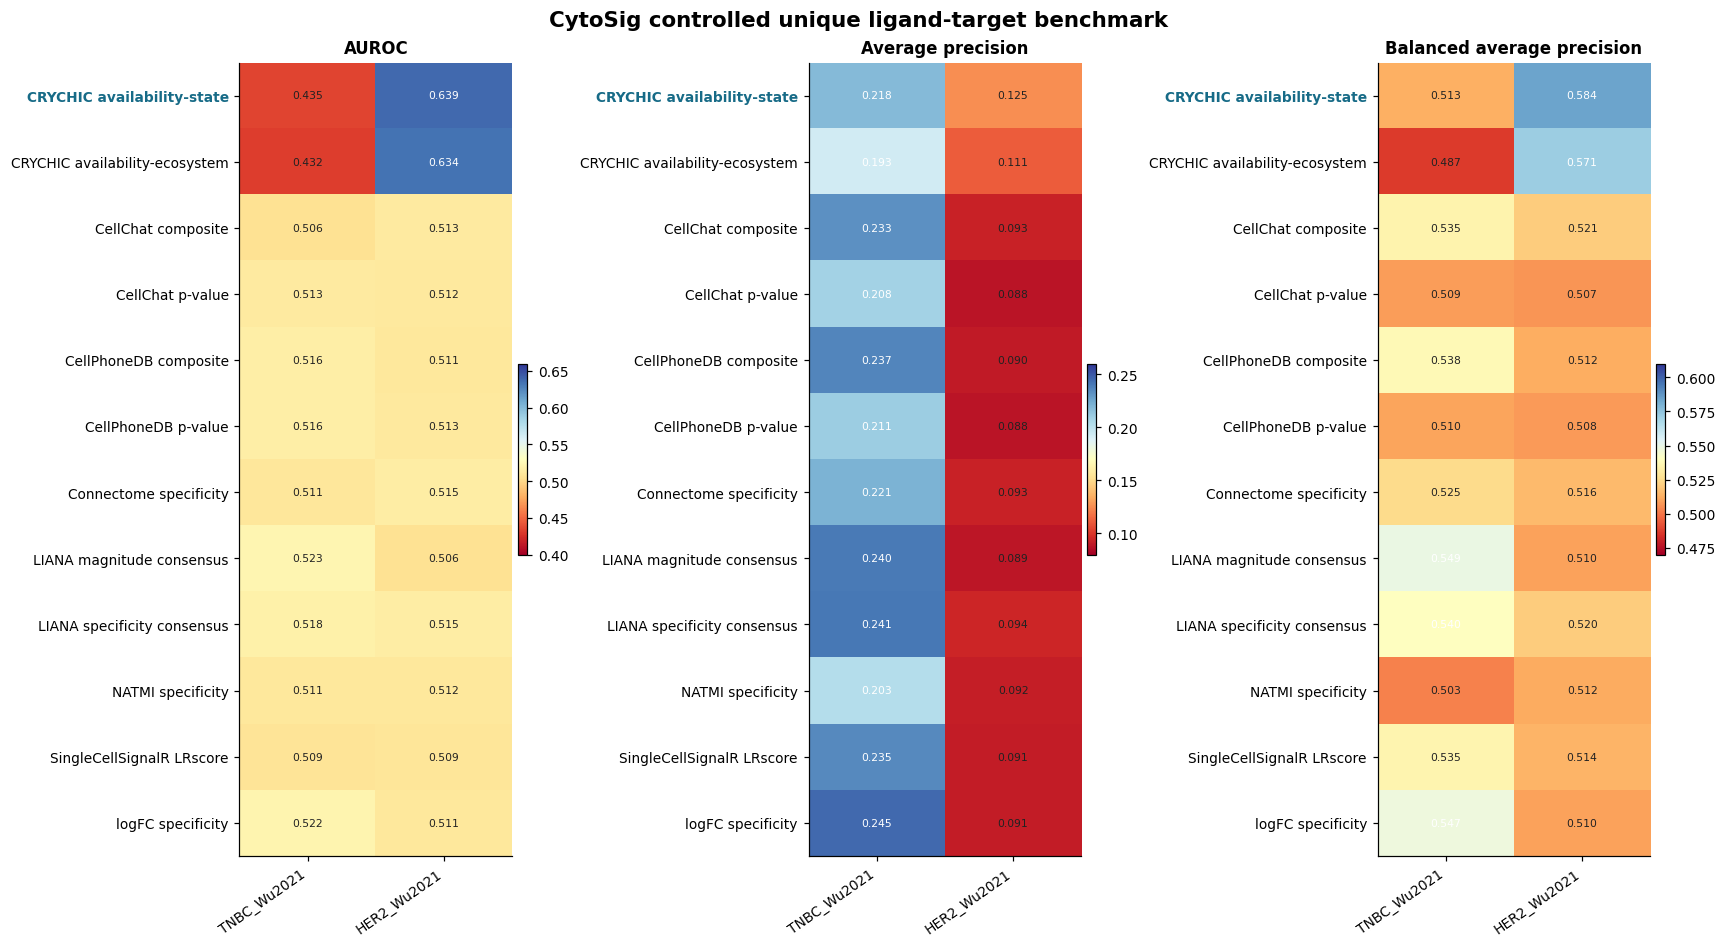

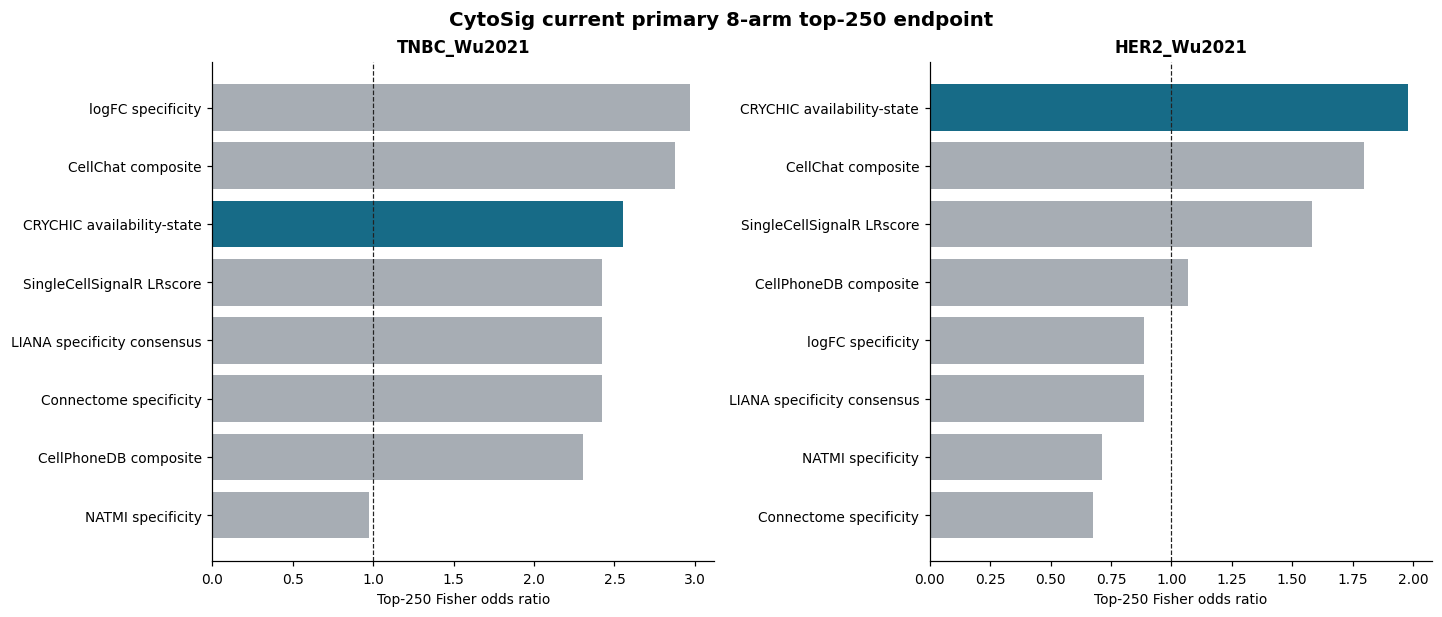

CPU times: user 1.99 s, sys: 629 ms, total: 2.61 s
Wall time: 2.61 s


,dataset,odds_ratio,q_value_bh_primary_8arm,rank
171,TNBC_Wu2021,2.554384,2.948094e-11,3.0
507,HER2_Wu2021,1.979049,2.442769e-04,1.0


In [7]:
%%time
cyto_method_order = sorted(
    controlled["method_name"].unique(),
    key=lambda value: (
        value != "CRYCHIC availability-state",
        not value.startswith("CRYCHIC"),
        value,
    ),
)
cyto_dataset_order = [
    dataset
    for dataset in ("TNBC_Wu2021", "HER2_Wu2021")
    if dataset in set(controlled["dataset"])
]
fig, axes = plt.subplots(1, 3, figsize=(15.5, 8.5), constrained_layout=True)
for ax, (metric, label, limits) in zip(
    axes,
    (
        ("auroc", "AUROC", (0.40, 0.66)),
        ("average_precision", "Average precision", (0.08, 0.26)),
        (
            "balanced_average_precision_mean",
            "Balanced average precision",
            (0.47, 0.61),
        ),
    ),
    strict=True,
):
    pivot = (
        controlled.pivot(
            index="method_name", columns="dataset", values=metric
        )
        .reindex(index=cyto_method_order, columns=cyto_dataset_order)
    )
    draw_heatmap(
        ax,
        pivot,
        title=label,
        vmin=limits[0],
        vmax=limits[1],
        cmap="RdYlBu",
    )
fig.suptitle(
    "CytoSig controlled unique ligand-target benchmark",
    fontsize=14,
    fontweight="bold",
)
cyto_metric_figure = OUTPUT_ROOT / "cytosig_controlled_metrics.png"
fig.savefig(cyto_metric_figure, bbox_inches="tight")
plt.show()

if not top250.empty:
    top_datasets = [
        value
        for value in ("TNBC_Wu2021", "HER2_Wu2021")
        if value in set(top250["dataset"])
    ]
    fig, axes = plt.subplots(
        1, len(top_datasets), figsize=(13, 5.5), constrained_layout=True
    )
    axes = np.atleast_1d(axes)
    for ax, dataset in zip(axes, top_datasets, strict=True):
        plot_data = top250.loc[top250["dataset"].eq(dataset)].sort_values(
            "odds_ratio", kind="stable"
        )
        colors = np.where(
            plot_data["method_id"].eq("crychic_availability_state"),
            CRYCHIC_COLOR,
            EXTERNAL_COLOR,
        )
        ax.barh(plot_data["method_name"], plot_data["odds_ratio"], color=colors)
        ax.axvline(1.0, color="#222222", linestyle="--", linewidth=0.8)
        ax.set_xlabel("Top-250 Fisher odds ratio")
        ax.set_title(dataset)
    fig.suptitle(
        "CytoSig current primary 8-arm top-250 endpoint",
        fontsize=13,
        fontweight="bold",
    )
    cyto_or_figure = OUTPUT_ROOT / "cytosig_top250_odds_ratio.png"
    fig.savefig(cyto_or_figure, bbox_inches="tight")
    plt.show()

top250_state


## 4. IPF：完整 56-patient 队列

每位患者使用相同的 960-edge H-common representable universe，其中 53 条为 disease-level curated positives。患者等权是主聚合；未标注 complement 是 operational pseudo-negative，不是实验验证阴性。Bootstrap 为 4-study 分层、2,000 次重采样，区间描述患者异质性，不是方法优越性的显著性检验。


In [8]:
%%time
ipf_primary = pd.read_csv(
    PUBLIC_ROOT / "tables/ipf_primary_metrics.tsv", sep="	"
)
ipf_patient = pd.read_csv(
    PUBLIC_ROOT / "ipf/cohort_patient_equal.tsv", sep="	"
)
ipf_study = pd.read_csv(
    PUBLIC_ROOT / "ipf/metrics_by_study.tsv", sep="	"
)
ipf_bootstrap = pd.read_csv(
    PUBLIC_ROOT / "ipf/patient_bootstrap.tsv", sep="	"
)
main_metrics = ("auroc", "average_precision", "balanced_auprc")
main_rows = ipf_patient.loc[ipf_patient["metric"].isin(main_metrics)].copy()
assert not main_rows.duplicated(["method", "metric"]).any()
assert main_rows["n_evaluable"].eq(56).all()
assert main_rows["status"].eq("complete").all()
assert ipf_primary["method"].nunique() == 11

reconstructed = main_rows.pivot(
    index="method", columns="metric", values="patient_equal_mean"
).reindex(ipf_primary["method"])
assert np.allclose(
    reconstructed.loc[:, list(main_metrics)].to_numpy(),
    ipf_primary.loc[:, list(main_metrics)].to_numpy(),
    rtol=0.0,
    atol=5e-7,
)

ipf_crychic = ipf_primary.loc[
    ipf_primary["method"].eq("CRYCHIC availability-state")
].copy()
assert int(ipf_crychic["auroc_rank"].iloc[0]) == 2
assert int(ipf_crychic["average_precision_rank"].iloc[0]) == 1
assert int(ipf_crychic["balanced_auprc_rank"].iloc[0]) == 1

ipf_crychic_bootstrap = ipf_bootstrap.loc[
    ipf_bootstrap["method"].eq("CRYCHIC availability-state")
    & ipf_bootstrap["metric"].isin(main_metrics)
].copy()
assert ipf_crychic_bootstrap["n_bootstrap"].eq(2000).all()
ipf_crychic_study = ipf_study.loc[
    ipf_study["method"].eq("CRYCHIC availability-state")
    & ipf_study["metric"].isin(main_metrics)
].copy()
assert ipf_crychic_study["study_id"].nunique() == 4
ipf_crychic


CPU times: user 10.2 ms, sys: 85 μs, total: 10.3 ms
Wall time: 9.62 ms


,method,auroc,average_precision,balanced_auprc,auroc_rank,average_precision_rank,balanced_auprc_rank,n_patients
1,CRYCHIC availability-state,0.585464,0.177687,0.651724,2,1,1,56


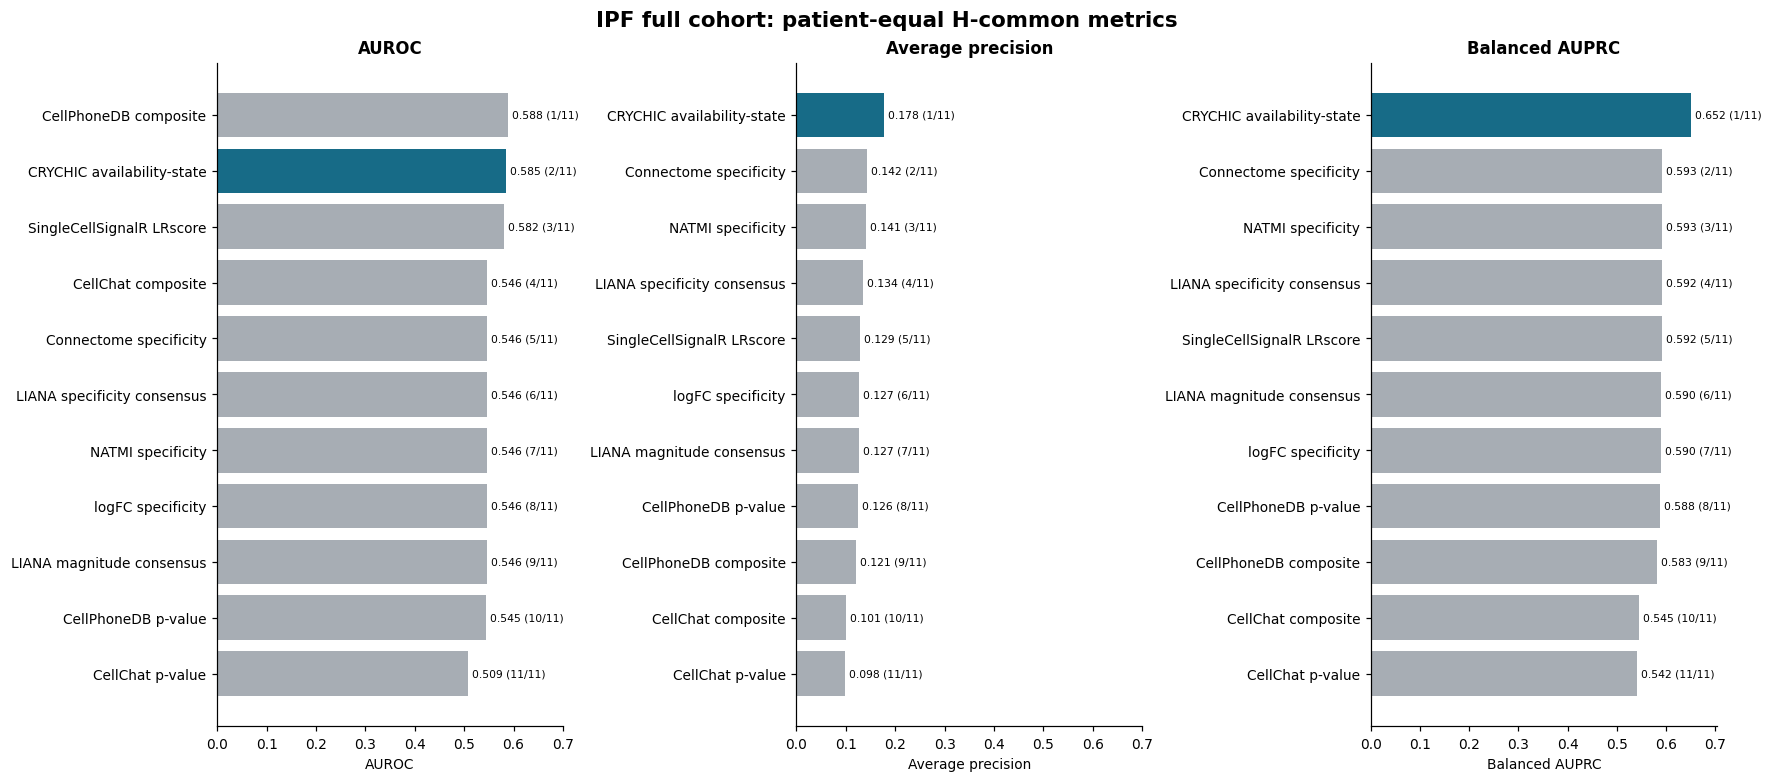

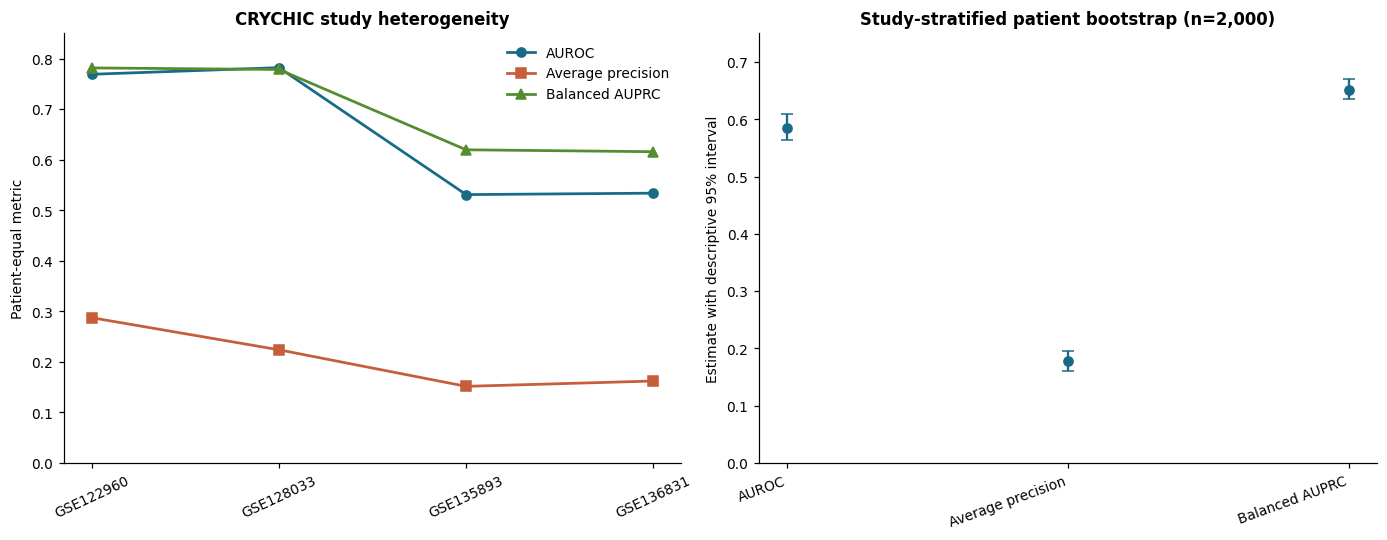

CPU times: user 1.47 s, sys: 275 ms, total: 1.74 s
Wall time: 1.74 s


In [9]:
%%time
metric_labels = {
    "auroc": "AUROC",
    "average_precision": "Average precision",
    "balanced_auprc": "Balanced AUPRC",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)
for ax, metric in zip(axes, main_metrics, strict=True):
    rank_column = {
        "auroc": "auroc_rank",
        "average_precision": "average_precision_rank",
        "balanced_auprc": "balanced_auprc_rank",
    }[metric]
    plot_data = ipf_primary.sort_values(metric, kind="stable")
    colors = np.where(
        plot_data["method"].eq("CRYCHIC availability-state"),
        CRYCHIC_COLOR,
        EXTERNAL_COLOR,
    )
    ax.barh(plot_data["method"], plot_data[metric], color=colors)
    ax.set_xlabel(metric_labels[metric])
    ax.set_xlim(0.0, max(0.70, float(plot_data[metric].max()) * 1.08))
    ax.set_title(metric_labels[metric])
    for y, row in enumerate(plot_data.itertuples(index=False)):
        value = getattr(row, metric)
        rank = getattr(row, rank_column)
        ax.text(value + 0.008, y, f"{value:.3f} ({int(rank)}/11)", va="center", fontsize=7)
fig.suptitle(
    "IPF full cohort: patient-equal H-common metrics",
    fontsize=14,
    fontweight="bold",
)
ipf_method_figure = OUTPUT_ROOT / "ipf_patient_equal_methods.png"
fig.savefig(ipf_method_figure, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
study_order = sorted(ipf_crychic_study["study_id"].unique())
for metric, color, marker in zip(
    main_metrics,
    (CRYCHIC_COLOR, ACCENT_COLOR, "#548C2F"),
    ("o", "s", "^"),
    strict=True,
):
    data = (
        ipf_crychic_study.loc[ipf_crychic_study["metric"].eq(metric)]
        .set_index("study_id")
        .reindex(study_order)
    )
    axes[0].plot(
        study_order,
        data["patient_equal_mean"],
        marker=marker,
        color=color,
        linewidth=1.8,
        label=metric_labels[metric],
    )
axes[0].set_ylim(0.0, 0.85)
axes[0].set_ylabel("Patient-equal metric")
axes[0].set_title("CRYCHIC study heterogeneity")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(frameon=False)

bootstrap_order = list(main_metrics)
bootstrap_data = (
    ipf_crychic_bootstrap.set_index("metric").reindex(bootstrap_order)
)
values = bootstrap_data["full_sample_estimate"].to_numpy(dtype=float)
lower = values - bootstrap_data["ci_lower"].to_numpy(dtype=float)
upper = bootstrap_data["ci_upper"].to_numpy(dtype=float) - values
axes[1].errorbar(
    range(len(bootstrap_order)),
    values,
    yerr=np.vstack([lower, upper]),
    fmt="o",
    color=CRYCHIC_COLOR,
    capsize=4,
    linewidth=1.5,
)
axes[1].set_xticks(
    range(len(bootstrap_order)),
    [metric_labels[value] for value in bootstrap_order],
    rotation=20,
    ha="right",
)
axes[1].set_ylim(0.0, 0.75)
axes[1].set_ylabel("Estimate with descriptive 95% interval")
axes[1].set_title("Study-stratified patient bootstrap (n=2,000)")
ipf_support_figure = OUTPUT_ROOT / "ipf_study_and_bootstrap.png"
fig.savefig(ipf_support_figure, bbox_inches="tight")
plt.show()


## 5. Top-250 稳健性

Recovery 是相对每个方法自身未扰动 top-250 的重现率，不是 biological accuracy。完整实验包含 8 个方法、4 类扰动、9 个比例和每点 5 次重复。CRYCHIC 的 normalized recovery AUC macro 为 0.807，排名 3/8；这里同样不声称全面第一。


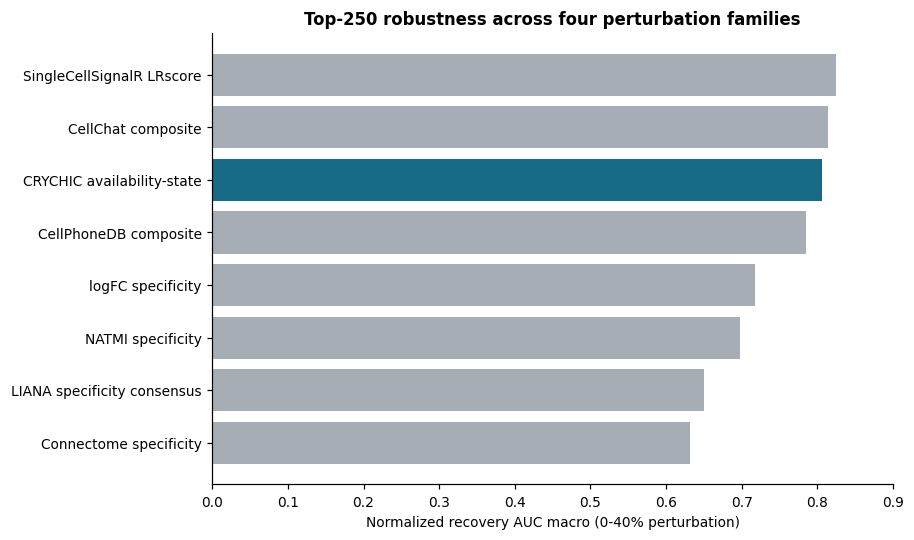

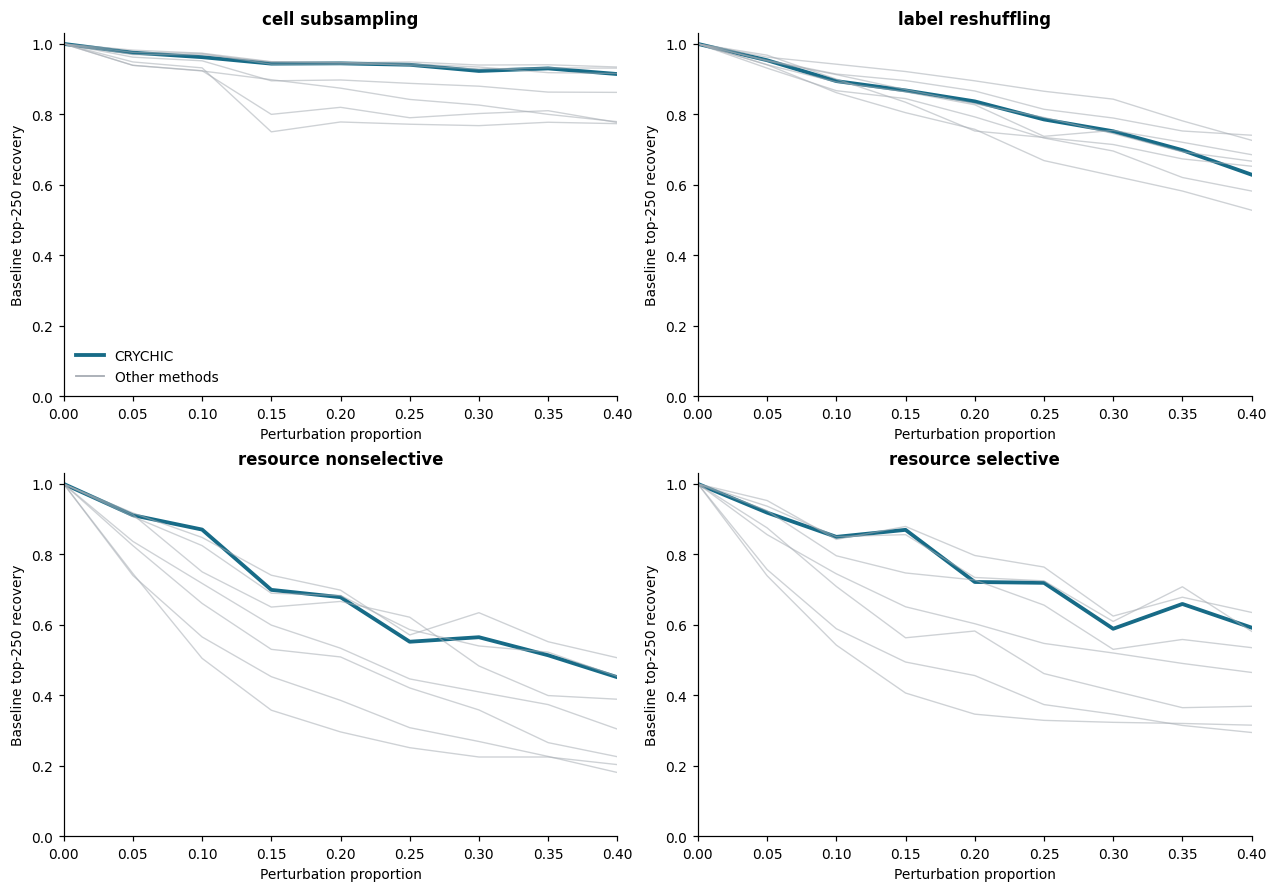

CPU times: user 1.24 s, sys: 137 ms, total: 1.38 s
Wall time: 1.38 s


In [10]:
%%time
robustness_available = LITERATURE_ROOT is not None and (
    LITERATURE_ROOT / "robustness/evaluation_full/manifest.json"
).is_file()
if robustness_available:
    robustness_root = LITERATURE_ROOT / "robustness/evaluation_full"
    robustness_manifest = read_json(robustness_root / "manifest.json")
    assert robustness_manifest["status"] == "complete"
    robustness_summary_path = robustness_root / "method_robustness_summary.tsv"
    robustness_curves_path = robustness_root / "top250_overlap_summary.tsv"
    assert sha256_file(robustness_summary_path) == robustness_manifest[
        "outputs"
    ]["method_robustness_summary.tsv"]["sha256"]
    assert sha256_file(robustness_curves_path) == robustness_manifest[
        "outputs"
    ]["top250_overlap_summary.tsv"]["sha256"]
    robustness_summary = pd.read_csv(robustness_summary_path, sep="	")
    robustness_curves = pd.read_csv(robustness_curves_path, sep="	")
    robustness_macro = (
        robustness_summary.loc[
            :,
            [
                "method",
                "normalized_recovery_auc_macro",
                "recovery_mean_at_40_macro",
                "jaccard_mean_at_40_macro",
            ],
        ]
        .drop_duplicates()
        .sort_values("normalized_recovery_auc_macro", ascending=False)
        .reset_index(drop=True)
    )
    robustness_macro["rank"] = np.arange(1, len(robustness_macro) + 1)
    assert len(robustness_macro) == 8
    assert int(
        robustness_macro.loc[
            robustness_macro["method"].eq("CRYCHIC availability-state"),
            "rank",
        ].iloc[0]
    ) == 3

    plot_data = robustness_macro.sort_values(
        "normalized_recovery_auc_macro", kind="stable"
    )
    colors = np.where(
        plot_data["method"].eq("CRYCHIC availability-state"),
        CRYCHIC_COLOR,
        EXTERNAL_COLOR,
    )
    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    ax.barh(
        plot_data["method"],
        plot_data["normalized_recovery_auc_macro"],
        color=colors,
    )
    ax.set_xlim(0.0, 0.9)
    ax.set_xlabel("Normalized recovery AUC macro (0-40% perturbation)")
    ax.set_title("Top-250 robustness across four perturbation families")
    robustness_bar = OUTPUT_ROOT / "robustness_macro_auc.png"
    fig.savefig(robustness_bar, bbox_inches="tight")
    plt.show()

    perturbations = sorted(robustness_curves["perturbation"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8), constrained_layout=True)
    for ax, perturbation in zip(axes.flat, perturbations, strict=True):
        subset = robustness_curves.loc[
            robustness_curves["perturbation"].eq(perturbation)
        ]
        for method, method_rows in subset.groupby("method", observed=True):
            is_crychic = method == "CRYCHIC availability-state"
            ax.plot(
                method_rows["proportion"],
                method_rows["baseline_recovery_mean"],
                color=CRYCHIC_COLOR if is_crychic else EXTERNAL_COLOR,
                linewidth=2.5 if is_crychic else 0.9,
                alpha=1.0 if is_crychic else 0.55,
            )
        ax.set_ylim(0.0, 1.03)
        ax.set_xlim(0.0, 0.4)
        ax.set_title(perturbation.replace("_", " "))
        ax.set_xlabel("Perturbation proportion")
        ax.set_ylabel("Baseline top-250 recovery")
    axes[0, 0].legend(
        handles=[
            Line2D([0], [0], color=CRYCHIC_COLOR, linewidth=2.5, label="CRYCHIC"),
            Line2D([0], [0], color=EXTERNAL_COLOR, linewidth=1.2, label="Other methods"),
        ],
        frameon=False,
    )
    robustness_curve_figure = OUTPUT_ROOT / "robustness_recovery_curves.png"
    fig.savefig(robustness_curve_figure, bbox_inches="tight")
    plt.show()
    robustness_macro
else:
    robustness_macro = pd.DataFrame()
    print("Workspace-only robustness detail is unavailable; skipped.")


## 6. CRYCHIC 分指标名次

下表保留每个 dataset/estimand 的方法数，不把不同 truth、物种资源或指标平均成一个“总分”。`rank=1` 表示该局部比较第一；native CITE-seq 因资源不一致不进入此 scorecard。


In [11]:
%%time
score_records = []
for row in cite_crychic_ranks.itertuples(index=False):
    score_records.append(
        {
            "benchmark": "CITE-seq H-common",
            "dataset": row.short_name,
            "metric": row.metric,
            "value": row.value,
            "rank": int(row.rank),
            "methods": int(row.methods),
        }
    )
for row in cyto_state_ranks.itertuples(index=False):
    score_records.append(
        {
            "benchmark": "CytoSig controlled",
            "dataset": row.dataset,
            "metric": row.metric,
            "value": row.value,
            "rank": int(row.rank),
            "methods": int(row.methods),
        }
    )
ipf_row = ipf_crychic.iloc[0]
for metric, label, rank_column in (
    ("auroc", "AUROC", "auroc_rank"),
    ("average_precision", "AP", "average_precision_rank"),
    ("balanced_auprc", "balanced AUPRC", "balanced_auprc_rank"),
):
    score_records.append(
        {
            "benchmark": "IPF patient-equal",
            "dataset": "56 patients / 4 studies",
            "metric": label,
            "value": ipf_row[metric],
            "rank": int(ipf_row[rank_column]),
            "methods": 11,
        }
    )
if not robustness_macro.empty:
    row = robustness_macro.loc[
        robustness_macro["method"].eq("CRYCHIC availability-state")
    ].iloc[0]
    score_records.append(
        {
            "benchmark": "Top-250 robustness",
            "dataset": "4 perturbation families",
            "metric": "normalized recovery AUC macro",
            "value": row["normalized_recovery_auc_macro"],
            "rank": int(row["rank"]),
            "methods": len(robustness_macro),
        }
    )

scorecard = pd.DataFrame(score_records)
scorecard["rank_display"] = (
    scorecard["rank"].astype(str) + "/" + scorecard["methods"].astype(str)
)
scorecard_summary = (
    scorecard.assign(
        first=lambda frame: frame["rank"].eq(1),
        top_two=lambda frame: frame["rank"].le(2),
    )
    .groupby("benchmark", observed=True)
    .agg(
        comparisons=("rank", "size"),
        first_place=("first", "sum"),
        top_two=("top_two", "sum"),
        median_rank=("rank", "median"),
    )
    .reset_index()
)
print(scorecard_summary.to_string(index=False))
scorecard.loc[
    :,
    ["benchmark", "dataset", "metric", "value", "rank_display"],
].sort_values(["benchmark", "dataset", "metric"], kind="stable")


         benchmark  comparisons  first_place  top_two  median_rank
 CITE-seq H-common           12            8        9          1.0
CytoSig controlled            6            3        3          4.5
 IPF patient-equal            3            2        3          1.0
Top-250 robustness            1            0        0          3.0
CPU times: user 10.6 ms, sys: 1.25 ms, total: 11.9 ms
Wall time: 11.1 ms


,benchmark,dataset,metric,value,rank_display
6,CITE-seq H-common,5k_pbmc,AP,0.108965,1/11
0,CITE-seq H-common,5k_pbmc,AUROC,0.548635,1/11
7,CITE-seq H-common,5k_pbmc_nextgem,AP,0.070353,11/11
1,CITE-seq H-common,5k_pbmc_nextgem,AUROC,0.465043,6/11
9,CITE-seq H-common,malt_10k,AP,0.174180,1/11
3,CITE-seq H-common,malt_10k,AUROC,0.590926,1/11
8,CITE-seq H-common,pbmc_10k,AP,0.174635,1/11
2,CITE-seq H-common,pbmc_10k,AUROC,0.641593,1/11
10,CITE-seq H-common,sln_111,AP,0.199296,4/9
4,CITE-seq H-common,sln_111,AUROC,0.626157,1/9


## 7. 最新源码单样本逐行一致性

这里读取的是用当前源码重新计算后的独立结果目录，而不是只重新绘制旧表。
可共同定义的 `availability_state` 做逐行键和值比较；需要跨条件训练信息的
RC12/RC14 保留为 NE。

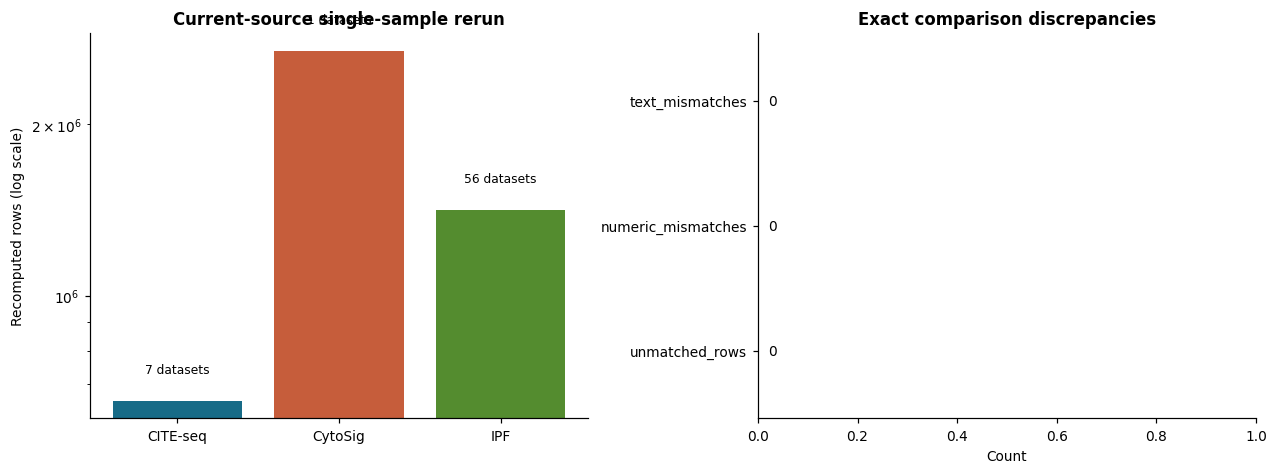

,track,datasets,old_rows,new_rows,unmatched_rows,numeric_mismatches,text_mismatches,max_absolute_numeric_difference,exactly_consistent
0,CITE-seq,7,653647,653647.0,0.0,0.0,0.0,0.0,True
1,CytoSig,1,2692500,2692500.0,0.0,0.0,0.0,0.0,True
2,IPF,56,1411457,1411457.0,0.0,0.0,0.0,0.0,True


,score_head,scenario,status,reason_code
0,availability_state,single_sample,complete,NaN
1,RC12_sender_response_detection,single_sample,NE,requires_train_derived_sender_assignment_and_b...
2,RC14_differential_DES,single_sample,NE,requires_multicondition_differential_statistic...


CPU times: user 584 ms, sys: 64.1 ms, total: 648 ms
Wall time: 647 ms


In [12]:
%%time
from IPython.display import display

gap_candidates = []
if os.environ.get("CRYCHIC_GAP_RESULT_ROOT"):
    gap_candidates.append(
        Path(os.environ["CRYCHIC_GAP_RESULT_ROOT"]).expanduser()
    )
for ancestor in (REPO_ROOT, *REPO_ROOT.parents):
    gap_candidates.append(
        ancestor
        / "benchmark_work"
        / "suggest_v5_gap_completion_20260724"
    )
GAP_ROOT = next(
    path.resolve()
    for path in gap_candidates
    if (path / "single_sample_consistency/manifest.json").is_file()
)

single_root = GAP_ROOT / "single_sample_consistency"
single_manifest = read_json(single_root / "manifest.json")
assert single_manifest["status"] == "complete_with_declared_NE"
assert single_manifest["source_repository"]["dirty"] is False
for relative, record in single_manifest["artifacts"].items():
    assert sha256_file(single_root / relative) == record["sha256"]

single_consistency = pd.read_csv(
    single_root / "track_summary.tsv", sep="	"
)
score_head_coverage = pd.read_csv(
    single_root / "score_head_coverage.tsv", sep="	"
)
assert int(single_consistency["datasets"].sum()) == 64
assert int(single_consistency["old_rows"].sum()) == 4_757_604
assert single_consistency["exactly_consistent"].astype(bool).all()
assert single_consistency[
    ["unmatched_rows", "numeric_mismatches", "text_mismatches"]
].fillna(0).to_numpy().sum() == 0
assert set(score_head_coverage.loc[
    score_head_coverage["status"].eq("NE"), "score_head"
]) == {"RC12_sender_response_detection", "RC14_differential_DES"}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
axes[0].bar(
    single_consistency["track"],
    single_consistency["new_rows"],
    color=[CRYCHIC_COLOR, ACCENT_COLOR, "#548C2F"],
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Recomputed rows (log scale)")
axes[0].set_title("Current-source single-sample rerun")
for index, row in single_consistency.reset_index(drop=True).iterrows():
    axes[0].text(
        index,
        row["new_rows"] * 1.12,
        f"{int(row['datasets'])} datasets",
        ha="center",
        fontsize=8,
    )

mismatch_columns = [
    "unmatched_rows", "numeric_mismatches", "text_mismatches"
]
mismatch_values = single_consistency[mismatch_columns].fillna(0).sum()
axes[1].barh(mismatch_values.index, mismatch_values.values, color=EXTERNAL_COLOR)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Count")
axes[1].set_title("Exact comparison discrepancies")
for index, value in enumerate(mismatch_values):
    axes[1].text(0.02, index, str(int(value)), va="center")
single_figure = OUTPUT_ROOT / "latest_single_sample_consistency.png"
fig.savefig(single_figure, bbox_inches="tight")
plt.show()

display(single_consistency)
display(score_head_coverage)

逐行一致性覆盖 CITE-seq 7 个数据集、IPF 56 位患者和 HER2 CytoSig，
共 64 个数据集、4,757,604 行；未匹配行、数值差异、文本差异和最大绝对
数值差均为 0。因此本 notebook 前面展示的同一单样本 estimand 的 AUROC、
AP 和排名保持不变。TNBC prepared H5AD 未保留，故当前重跑为 NE，未放入
一致性分母。

RC12 需要训练折生成的 sender assignment 和跨条件 receiver program；
RC14 需要多条件差异统计及空间 pair prior。它们不是单样本 score head，
不能用 receptor expression 临时替代。

## 8. suggest_v5 剩余端点补齐

下表汇总实际运行后的状态。`complete_diagnostic` 与
`diagnostic_nonconverged` 不等同于正式推断完成，NE 也不计为零分。

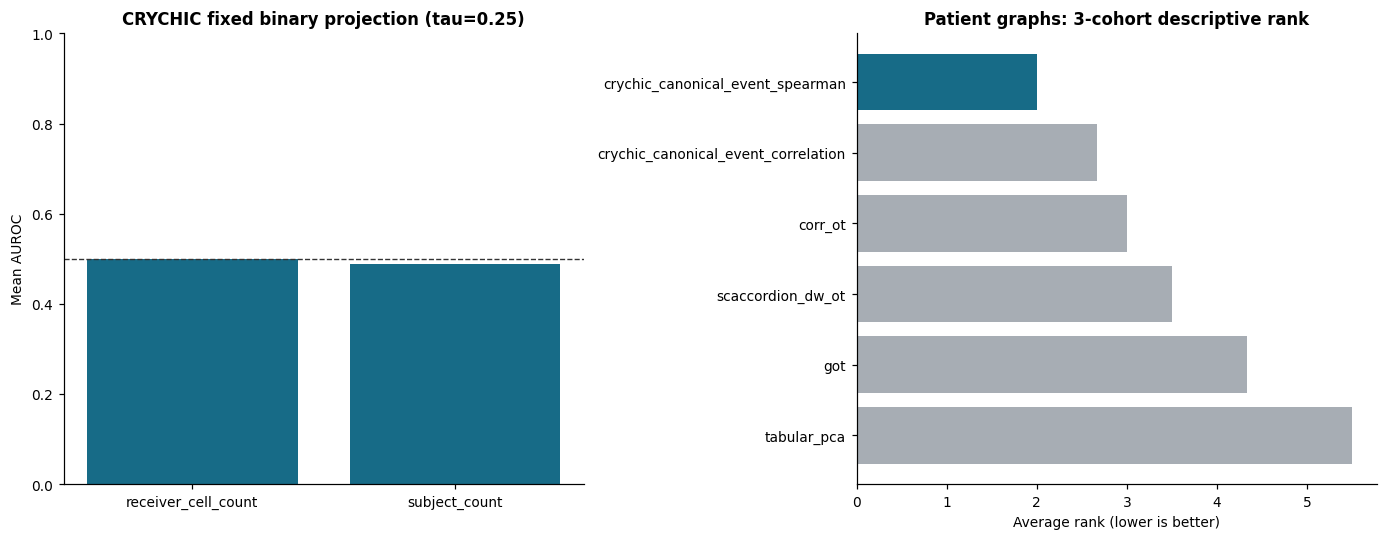

,endpoint,status,source_commit
0,Tensor extended,complete,4d8427eec3b0
1,STACCato calibration,complete_with_declared_NE,4d8427eec3b0
2,DCST fixed binary,complete,4d8427eec3b0
3,scACCorDiON PDAC,complete_with_declared_NE,9f758851c7af
4,scACCorDiON AKI,complete_with_declared_NE,9f758851c7af
5,scACCorDiON RCC fine,complete_with_declared_NE,9f758851c7af
6,scACCorDiON RCC coarse,complete_with_declared_NE_and_numerical_diagno...,9f758851c7af
7,Cross-cohort ranks,complete_descriptive_low_n,9f758851c7af
8,TCGA-PAAD survival,complete,4d8427eec3b0


,benchmark,endpoint,status,reason_code
0,Tensor,extended_factor_metrics,complete,
1,Tensor,CorrIndex,NE,single_score_generator_no_pairwise_decomposition
2,Tensor,strict_or_partial_hyperedge_recovery,NE,simulation_truth_contains_simple_lr_events_not...
3,Tensor,signed_event_recovery,NE,nonnegative_tensor_simulation_has_no_signed_truth
4,STACCato,disease_and_batch_effect_error,complete,
5,STACCato,null_type1_and_empirical_fdr,complete_diagnostic,model_stage_residual_bootstrap
6,STACCato,interval_coverage_and_width,complete_diagnostic,model_stage_residual_bootstrap
7,STACCato,power_by_effect_and_subject_count,complete_diagnostic,model_stage_residual_bootstrap
8,STACCato,formal_full_pipeline_p_q,NE,upstream_score_generation_not_resampled
9,STACCato,CRYCHIC_common_functional_OOF,NE,unpaired_subject_context_design


,sweep,method,auroc_mean,auprc_mean,sensitivity_q005_mean
0,receiver_cell_count,crychic_fixed_binary_tau_0.25,0.5000,0.25,0.0
1,subject_count,crychic_fixed_binary_tau_0.25,0.4893,0.25,0.0


,method,average_rank,rank,cohorts,friedman_statistic,friedman_p_value
0,crychic_canonical_event_spearman,2.0000,1,3,8.4524,0.133
1,crychic_canonical_event_correlation,2.6667,2,3,8.4524,0.133
2,corr_ot,3.0000,3,3,8.4524,0.133
3,scaccordion_dw_ot,3.5000,4,3,8.4524,0.133
4,got,4.3333,5,3,8.4524,0.133
5,tabular_pca,5.5000,6,3,8.4524,0.133


CPU times: user 441 ms, sys: 67.2 ms, total: 509 ms
Wall time: 507 ms


In [13]:
%%time
gap_runs = {
    "Tensor extended": GAP_ROOT / "tensor_extended",
    "STACCato calibration": GAP_ROOT / "staccato",
    "DCST fixed binary": GAP_ROOT / "dcst_binary",
    "scACCorDiON PDAC": GAP_ROOT / "scaccordion_pdac_v2",
    "scACCorDiON AKI": GAP_ROOT / "scaccordion_aki_v2",
    "scACCorDiON RCC fine": GAP_ROOT / "scaccordion_rcc_v2",
    "scACCorDiON RCC coarse": GAP_ROOT / "scaccordion_rcc_coarse_v2",
    "Cross-cohort ranks": GAP_ROOT / "scaccordion_crosscohort_v2",
    "TCGA-PAAD survival": GAP_ROOT / "tcga_paad_survival",
}
gap_inventory = []
for label, directory in gap_runs.items():
    manifest = read_json(directory / "manifest.json")
    source = manifest.get("source_repository", {})
    assert source.get("dirty") is False
    gap_inventory.append(
        {
            "endpoint": label,
            "status": manifest["status"],
            "source_commit": source.get("commit", "")[:12],
        }
    )
gap_inventory = pd.DataFrame(gap_inventory)

coverage_frames = []
for label, relative in (
    ("Tensor", "tensor_extended/endpoint_coverage.tsv"),
    ("STACCato", "staccato/endpoint_coverage.tsv"),
    ("PDAC", "scaccordion_pdac_v2/endpoint_coverage.tsv"),
    ("AKI", "scaccordion_aki_v2/endpoint_coverage.tsv"),
    ("RCC fine", "scaccordion_rcc_v2/endpoint_coverage.tsv"),
    ("RCC coarse", "scaccordion_rcc_coarse_v2/endpoint_coverage.tsv"),
):
    frame = pd.read_csv(GAP_ROOT / relative, sep="	").fillna("")
    frame.insert(0, "benchmark", label)
    coverage_frames.append(frame)
gap_coverage = pd.concat(coverage_frames, ignore_index=True)

dcst_binary = pd.read_csv(
    GAP_ROOT / "dcst_binary/aggregate_metrics.tsv", sep="	"
)
dcst_binary_summary = (
    dcst_binary.groupby(["sweep", "method"], observed=True)[
        ["auroc_mean", "auprc_mean", "sensitivity_q005_mean"]
    ]
    .mean()
    .reset_index()
)
cross_ranks = pd.read_csv(
    GAP_ROOT / "scaccordion_crosscohort_v2/friedman_average_ranks.tsv",
    sep="	",
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
axes[0].bar(
    dcst_binary_summary["sweep"],
    dcst_binary_summary["auroc_mean"],
    color=CRYCHIC_COLOR,
)
axes[0].axhline(0.5, color="#333333", linestyle="--", linewidth=0.9)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Mean AUROC")
axes[0].set_title("CRYCHIC fixed binary projection (tau=0.25)")

rank_plot = cross_ranks.sort_values("average_rank", ascending=False)
rank_colors = np.where(
    rank_plot["method"].eq("crychic_canonical_event_spearman"),
    CRYCHIC_COLOR,
    EXTERNAL_COLOR,
)
axes[1].barh(rank_plot["method"], rank_plot["average_rank"], color=rank_colors)
axes[1].set_xlabel("Average rank (lower is better)")
axes[1].set_title("Patient graphs: 3-cohort descriptive rank")
gap_figure = OUTPUT_ROOT / "suggest_v5_gap_completion.png"
fig.savefig(gap_figure, bbox_inches="tight")
plt.show()

display(gap_inventory)
display(gap_coverage)
display(dcst_binary_summary.round(4))
display(cross_ranks.round(4))

In [14]:
%%time
patient_rows = []
for cohort, relative in (
    ("PDAC", "scaccordion_pdac_v2/summary_metrics.tsv"),
    ("AKI", "scaccordion_aki_v2/summary_metrics.tsv"),
    ("RCC fine", "scaccordion_rcc_v2/summary_metrics.tsv"),
    ("RCC coarse", "scaccordion_rcc_coarse_v2/summary_metrics.tsv"),
):
    frame = pd.read_csv(GAP_ROOT / relative, sep="	")
    frame = frame.loc[
        frame["clustering_backend"].eq("kmedoids")
        & frame["method"].isin(
            [
                "crychic_canonical_event_spearman",
                "crychic_native_availability_hyperedge_spearman",
            ]
        )
    ].copy()
    frame.insert(0, "cohort", cohort)
    patient_rows.append(frame)
patient_crychic = pd.concat(patient_rows, ignore_index=True)

cox = pd.read_csv(
    GAP_ROOT / "tcga_paad_survival/cox_coefficients.tsv", sep="	"
)
survival_hits = cox.loc[
    cox["mode"].eq("ligand_receptor_geometric_mean")
    & cox["is_interaction_term"].astype(bool)
    & cox["q.value.within.mode"].lt(0.05),
    ["term", "estimate", "p.value", "q.value.within.mode"],
].rename(columns={"estimate": "hazard_ratio"})

staccato_coverage = pd.read_csv(
    GAP_ROOT / "staccato/endpoint_coverage.tsv", sep="	"
)
final_consistency = pd.DataFrame(
    [
        {
            "claim": "Latest estimable single-sample score",
            "result": "64/64 exact; 4,757,604/4,757,604 rows identical",
        },
        {
            "claim": "Existing single-sample AUROC/AP/ranks",
            "result": "unchanged because all score rows are identical",
        },
        {
            "claim": "RC12/RC14 on one sample",
            "result": "NE: requires between-condition training/statistics",
        },
        {
            "claim": "Patient-graph rank claim",
            "result": "CRYCHIC-compatible Spearman 1/6 descriptively; Friedman p=0.133",
        },
    ]
)
display(patient_crychic[
    [
        "cohort", "method", "ari_at_protocol_selected_true_k",
        "maximum_ari_over_grid", "numerical_status",
    ]
])
display(survival_hits.round(4))
display(staccato_coverage)
display(final_consistency)

,cohort,method,ari_at_protocol_selected_true_k,maximum_ari_over_grid,numerical_status
0,PDAC,crychic_canonical_event_spearman,1.000000,1.000000,converged
1,AKI,crychic_canonical_event_spearman,0.278722,0.278722,converged
2,AKI,crychic_native_availability_hyperedge_spearman,0.118842,0.157549,converged
3,RCC fine,crychic_canonical_event_spearman,1.000000,1.000000,converged
4,RCC fine,crychic_native_availability_hyperedge_spearman,1.000000,1.000000,converged
5,RCC coarse,crychic_canonical_event_spearman,0.764298,0.764298,converged
6,RCC coarse,crychic_native_availability_hyperedge_spearman,1.000000,1.000000,converged


,term,hazard_ratio,p.value,q.value.within.mode
6,MMP7_SDC1,1.4073,0.0054,0.027
11,C3_CD81,1.9794,0.0045,0.027


,endpoint,status,reason_code
0,disease_and_batch_effect_error,complete,NaN
1,null_type1_and_empirical_fdr,complete_diagnostic,model_stage_residual_bootstrap
2,interval_coverage_and_width,complete_diagnostic,model_stage_residual_bootstrap
3,power_by_effect_and_subject_count,complete_diagnostic,model_stage_residual_bootstrap
4,formal_full_pipeline_p_q,NE,upstream_score_generation_not_resampled
5,CRYCHIC_common_functional_OOF,NE,unpaired_subject_context_design


,claim,result
0,Latest estimable single-sample score,"64/64 exact; 4,757,604/4,757,604 rows identical"
1,Existing single-sample AUROC/AP/ranks,unchanged because all score rows are identical
2,RC12/RC14 on one sample,NE: requires between-condition training/statis...
3,Patient-graph rank claim,CRYCHIC-compatible Spearman 1/6 descriptively;...


CPU times: user 21.6 ms, sys: 1.63 ms, total: 23.2 ms
Wall time: 22.2 ms


PDAC cell downsampling remains NE because the released archive contains patient
graphs and metadata but not the author-processed cell-level H5AD. STACCato
full-pipeline p/q remains NE because the diagnostic residual bootstrap does not
resample upstream score generation. RCC-coarse correlation-OT k-barycenter is
retained as `diagnostic_nonconverged`. These boundaries prevent unavailable or
numerically invalid evidence from being converted into a zero or a favorable
score.

## 解释边界与重跑范围

- 本 notebook 已重新读取、校验和可视化冻结结果；它没有重新执行 7 个 CITE-seq、56 个 IPF patient tasks 或 CytoSig 原始模型。完整昂贵重跑应使用各 manifest 记录的 evaluator/runner，并写入新的版本目录，不能覆盖本发布 bundle。
- CITE-seq truth 直接验证 receiver receptor protein specificity；CytoSig 验证下游转录响应一致性；IPF 使用疾病级 curated open-world gold；robustness 只验证相对自身 baseline 的重现。四者不是同一个 estimand。
- `not_evaluable` 和 skipped arms 保留为状态，不补 0：CBMC H-common 无 truth overlap、mouse CellPhoneDB 不可用、CytoSig Crosstalk/论文冻结 OmniPath 不可用、IPF 旧 CCInx/iTALK/scMLnet 不可用；NicheNet 的 ligand-target estimand 不强行映射为 direct STLR 排名。
- 图中的 CellChat/CellPhoneDB `composite` 是当前 LIANA component arm，不是历史 standalone 软件环境的逐版本精确复现。
- 这些静态 benchmark 不能替代多组 subject-aware differential communication 验证，也不能单独证明 causal sender。多组 Kuppe/MS 正式任务应在完成后作为独立 benchmark 版本发布，不混入本次 complete 文献结果。
